# 🔬 Diagnóstico Grad-CAM: NIH Swin-Tiny vs Osteo VGG16-BN

## Problema
Las matrices de confusión del Router muestran que **58 imágenes Osteo (val) y 284 (train)** son enrutadas al experto NIH cuando deberían ir al experto de Osteoartritis.

## Objetivo
Ver con Grad-CAM en qué regiones se fija cada modelo ante las mismas radiografías para entender por qué el Router se confunde.

> Misma estructura de celdas que `05_Router_Profesor_Fase3_Solo.ipynb`.

In [22]:
!pip install -q SimpleITK torch torchvision timm grad-cam

import os
import glob
import random
import shutil
import subprocess
import warnings
import numpy as np
import cv2
from PIL import Image
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
import timm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pytorch_grad_cam import GradCAM, ScoreCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

warnings.filterwarnings('ignore')
random.seed(42)

# --- Rutas (igual que 05_Router_Profesor_Fase3_Solo.ipynb) ---
RAW_DIR     = "/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/"
LOCAL_DEST  = "/content/datasets/"
WEIGHTS_DIR = "/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/"
os.makedirs(LOCAL_DEST, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

DATASET_ROOTS = {
    "NIH":   (os.path.join(LOCAL_DEST, "NIH Chest X ray 14"), 0),
    "Osteo": (os.path.join(LOCAL_DEST, "Knee Osteoarthritis Classification"), 2),
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Rutas (datasets tras extracción en LOCAL_DEST):")
for k, (p, d) in DATASET_ROOTS.items():
    ok = os.path.isdir(p)
    print(f"  {k} id={d} exists={ok} -> {p}")
print(f"RAW_DIR={RAW_DIR}")
print(f"LOCAL_DEST={LOCAL_DEST}")
print(f"WEIGHTS_DIR={WEIGHTS_DIR}")
print(f"device={device}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rutas (datasets tras extracción en LOCAL_DEST):
  NIH id=0 exists=True -> /content/datasets/NIH Chest X ray 14
  Osteo id=2 exists=True -> /content/datasets/Knee Osteoarthritis Classification
RAW_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/
LOCAL_DEST=/content/datasets/
WEIGHTS_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/
device=cuda


## Fase 1: Extracción de datos a disco local

Copia los `.zip` de NIH y Osteo desde `RAW_DIR` (Google Drive) a `LOCAL_DEST` y los descomprime. **Misma lógica que `05_Router_Profesor_Fase3_Solo.ipynb`.**

Pon `RUN_EXTRACT_ZIPS = False` si las carpetas ya existen en `/content/datasets/`.

In [2]:
# ZIP_FILTER: solo descomprimir estos dos (None = todos como en el router)
ZIP_FILTER = ["NIH Chest X ray 14.zip", "Knee Osteoarthritis Classification.zip"]

def extract_datasets_colab(raw_dir=RAW_DIR, local_dest=LOCAL_DEST):
    """Copia ZIPs de Drive a /content/datasets/ y los descomprime (notebook 03)."""
    if not os.path.exists(raw_dir):
        print(f"Ruta {raw_dir} no existe. No se extrae nada.")
        return
    all_zips  = sorted([f for f in os.listdir(raw_dir) if f.lower().endswith(".zip")])
    zip_files = [z for z in all_zips if z in ZIP_FILTER]
    print(f"Encontrados {len(all_zips)} zips en Drive. Procesando {len(zip_files)}: {zip_files}")
    for zip_name in zip_files:
        print("=" * 60)
        print(f"Procesando: {zip_name}")
        drive_zip_path = os.path.join(raw_dir, zip_name)
        dataset_name   = os.path.splitext(zip_name)[0]
        unzip_dir      = os.path.join(local_dest, dataset_name)
        local_zip_path = os.path.join(local_dest, zip_name)
        if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
            print(f" Ya existe: {unzip_dir} (omitido).")
            continue
        print(" 1. Copiando ZIP...")
        shutil.copy2(drive_zip_path, local_zip_path)
        os.makedirs(unzip_dir, exist_ok=True)
        print(f" 2. Descomprimiendo en {unzip_dir}...")
        subprocess.run(["unzip", "-q", local_zip_path, "-d", unzip_dir], check=True)
        print(" 3. Borrando ZIP local.")
        os.remove(local_zip_path)
        # ZIPs internos
        for iz in glob.glob(os.path.join(unzip_dir, "**", "*.zip"), recursive=True):
            print(f" -> ZIP interno: {iz}")
            subprocess.run(["unzip", "-q", iz, "-d", os.path.dirname(iz)], check=True)
            os.remove(iz)
    print("\nExtracción completa.")


RUN_EXTRACT_ZIPS = True  # False si ya descomprimiste en esta sesión
if RUN_EXTRACT_ZIPS:
    extract_datasets_colab()
else:
    print("RUN_EXTRACT_ZIPS=False: se asume que LOCAL_DEST ya contiene los datasets.")

Encontrados 5 zips en Drive. Procesando 2: ['Knee Osteoarthritis Classification.zip', 'NIH Chest X ray 14.zip']
Procesando: Knee Osteoarthritis Classification.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/Knee Osteoarthritis Classification...
 3. Borrando ZIP local.
Procesando: NIH Chest X ray 14.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/NIH Chest X ray 14...
 3. Borrando ZIP local.

Extracción completa.


## Fase 2: Arquitecturas y carga de pesos

Copiadas exactamente de `05_Router_Profesor_Fase3_Solo.ipynb`.

In [23]:
# ── Experto 1 (NIH) — Swin-Tiny (timm), 5 clases multietiqueta ──
class SwinNIHClassifier(nn.Module):
    """Misma envoltura que SwinClassifier en el notebook de entrenamiento (timm)."""
    def __init__(self, num_classes: int = 5, pretrained: bool = False):
        super().__init__()
        self.model = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=num_classes,
        )
    def forward(self, x):
        return self.model(x)


# ── Experto 3 (Osteo) — VGG16-BN, entrada 1 canal ──────────────
def build_vgg16_bn(num_classes: int = 5, pretrained: bool = False):
    model = models.vgg16_bn(weights=None)
    old_conv = model.features[0]
    new_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
    with torch.no_grad():
        new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        new_conv.bias.copy_(old_conv.bias)
    model.features[0] = new_conv
    model.classifier = nn.Sequential(
        nn.Linear(512 * 7 * 7, 512), nn.ReLU(True), nn.BatchNorm1d(512), nn.Dropout(0.5),
        nn.Linear(512, 256),          nn.ReLU(True), nn.BatchNorm1d(256), nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


# ── Función de carga de pesos (idéntica a load_weights del router) ──
def load_weights(model, ckpt_path, map_location="cpu", strict=False):
    if not ckpt_path or not os.path.exists(ckpt_path):
        return False, f"checkpoint no encontrado: {ckpt_path}"
    raw = torch.load(ckpt_path, map_location=map_location)
    if isinstance(raw, dict):
        if   "state_dict"       in raw: state = raw["state_dict"]
        elif "model_state_dict" in raw: state = raw["model_state_dict"]
        elif "model" in raw and isinstance(raw["model"], dict): state = raw["model"]
        else:                           state = raw
    else:
        state = raw
    try:
        model.load_state_dict(state, strict=strict)
        return True, "ok"
    except Exception as e:
        return False, str(e)


# ── Rutas de pesos ─────────────────────────────────────────────
NIH_CKPT = os.path.join(WEIGHTS_DIR, "Experts_2D", "MaxViT_NIH_5cls.pth")
for alt in [
    os.path.join(WEIGHTS_DIR, "MaxViT_NIH_5cls.pth"),
    os.path.join(WEIGHTS_DIR, "exp1_NIH_LungMaxViT_best.pth"),
]:
    if not os.path.exists(NIH_CKPT) and os.path.exists(alt):
        NIH_CKPT = alt
OSTEO_CKPT = os.path.join(WEIGHTS_DIR, "exp3_Osteo_VGG16BN_best.pth")

# ── Instanciar y cargar ────────────────────────────────────────
nih_model = SwinNIHClassifier(num_classes=5, pretrained=False).to(device)
ok, msg = load_weights(nih_model, NIH_CKPT, map_location=str(device))
print(f"NIH  Swin-Tiny  -> {'OK' if ok else 'ERROR'} | {msg}")
nih_model.eval()

osteo_model = build_vgg16_bn(num_classes=5, pretrained=False).to(device)
ok, msg = load_weights(osteo_model, OSTEO_CKPT, map_location=str(device))
print(f"Osteo VGG16-BN  -> {'OK' if ok else 'ERROR'} | {msg}")
osteo_model.eval()

NIH_CLASSES   = ["Mass", "Nodule", "Effusion", "Cardiomegaly", "Pneumothorax"]
OSTEO_CLASSES = ["KL-0", "KL-1", "KL-2", "KL-3", "KL-4"]
print("Modelos cargados.")

# ── Verificar estructura interna para elegir capas GradCAM ────
print("\n--- VGG16-BN features[-1:-5:-1] ---")
for i, (idx, layer) in enumerate([
        (-1, osteo_model.features[-1]),
        (-2, osteo_model.features[-2]),
        (-3, osteo_model.features[-3]),
        (-4, osteo_model.features[-4]),
    ]):
    print(f"  features[{idx}]: {layer.__class__.__name__}")

NIH  Swin-Tiny  -> OK | ok
Osteo VGG16-BN  -> OK | ok
Modelos cargados.

--- VGG16-BN features[-1:-5:-1] ---
  features[-1]: MaxPool2d
  features[-2]: ReLU
  features[-3]: BatchNorm2d
  features[-4]: Conv2d


## Fase 3: AdaptivePreprocessor

Copia exacta de `05_Router_Profesor_Fase3_Solo.ipynb`.

In [24]:
class AdaptivePreprocessor:
    """Carga archivos y retorna tensores nativos (2D o 3D)."""
    def __init__(self, size_2d=(224, 224), size_3d=(64, 64, 64), hu_window_ct=(-1000, 400)):
        self.size_2d = size_2d
        self.size_3d = size_3d
        self.hu_min, self.hu_max = hu_window_ct

    def __call__(self, file_path):
        ext = file_path.lower()
        if ext.endswith(('.png', '.jpg', '.jpeg')): return self._process_2d(file_path)
        if ext.endswith('.mha'):                     return self._process_mha(file_path)
        if ext.endswith(('.mhd', '.nii.gz', '.nii')): return self._process_3d(file_path)
        raise ValueError(f'Formato no soportado: {file_path}')

    def _process_2d(self, path):
        img = Image.open(path).convert('RGB')
        transform = T.Compose([T.Resize(self.size_2d), T.ToTensor()])
        return transform(img)

    def _process_mha(self, path):
        itk_img = sitk.ReadImage(path)
        size = itk_img.GetSize()
        arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        if len(size) == 2:                       return self._array_2d_to_tensor(arr)
        if len(size) == 3 and size[2] <= 1:
            arr = np.squeeze(arr)
            if arr.ndim == 2:                    return self._array_2d_to_tensor(arr)
        return self._volume_array_to_tensor(arr, path)

    def _array_2d_to_tensor(self, arr):
        if arr.max() > 1.5:
            arr = arr / 255.0 if arr.max() > 2.0 else (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        t = torch.from_numpy(arr).unsqueeze(0)
        if t.shape[1:] != torch.Size(self.size_2d):
            t = F.interpolate(t.unsqueeze(0), size=self.size_2d, mode='bilinear', align_corners=False).squeeze(0)
        if t.shape[0] == 1:  t = t.repeat(3, 1, 1)
        elif t.shape[0] > 3: t = t[:3]
        return t

    def _volume_array_to_tensor(self, img_arr, path_hint=''):
        amin, amax = float(np.nanmin(img_arr)), float(np.nanmax(img_arr))
        pre_norm = amax <= 1.5 and amin >= -1e-2 and 'Pancreas' in str(path_hint).replace('\\', '/')
        if not pre_norm:
            img_arr = np.clip(img_arr, self.hu_min, self.hu_max)
            img_arr = (img_arr - self.hu_min) / (self.hu_max - self.hu_min + 1e-8)
        else:
            img_arr = np.clip(img_arr, 0.0, 1.0)
        t = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=self.size_3d, mode='trilinear', align_corners=False)
        return t.squeeze(0)

    def _process_3d(self, path):
        if path.endswith('.mhd'):
            itk_img = sitk.ReadImage(path)
            img_arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        else:
            import nibabel as nib
            nii_img = nib.load(path)
            img_arr = np.transpose(nii_img.get_fdata().astype(np.float32), (2, 1, 0))
        return self._volume_array_to_tensor(img_arr, path_hint=path)


preprocessor = AdaptivePreprocessor()
print('AdaptivePreprocessor listo.')

AdaptivePreprocessor listo.


## Fase 4: Selección de 3 imágenes de prueba

Busca automáticamente en los datasets descomprimidos.  
Edita `TEST_IMAGES` manualmente si quieres controlar qué imágenes usar.

In [15]:
NIH_ROOT   = DATASET_ROOTS["NIH"][0]
OSTEO_ROOT = DATASET_ROOTS["Osteo"][0]
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.mha')

def scan_dataset_files(root_path, max_files=None):
    """Escanea recursivamente y retorna paths de archivos médicos válidos."""
    files = []
    for dirpath, _, filenames in os.walk(root_path):
        for fname in sorted(filenames):
            if fname.lower().endswith(VALID_EXTENSIONS):
                files.append(os.path.join(dirpath, fname))
    if max_files:
        files = files[:max_files]
    return files

nih_files   = scan_dataset_files(NIH_ROOT,   max_files=500)
osteo_files = scan_dataset_files(OSTEO_ROOT, max_files=500)
print(f"Archivos NIH   encontrados : {len(nih_files)}")
print(f"Archivos Osteo encontrados : {len(osteo_files)}")

random.shuffle(nih_files)
random.shuffle(osteo_files)

# 3 Osteo + 3 NIH = 6 imágenes totales, intercaladas
N_PER_CLASS = 3
TEST_IMAGES = []
for i in range(N_PER_CLASS):
    if i < len(osteo_files):
        TEST_IMAGES.append({"path": osteo_files[i], "label": f"Osteo #{i+1}", "true_expert": "Osteo"})
    if i < len(nih_files):
        TEST_IMAGES.append({"path": nih_files[i], "label": f"NIH #{i+1}",   "true_expert": "NIH"})

print("\nImagenes seleccionadas:")
for i, t in enumerate(TEST_IMAGES):
    ok = os.path.exists(t["path"]) if t["path"] else False
    print(f"  [{i+1}] {t['label']:15s} | {'OK' if ok else 'FALTA'} | {t['path']}")

Archivos NIH   encontrados : 500
Archivos Osteo encontrados : 500

Imagenes seleccionadas:
  [1] Osteo #1        | OK | /content/datasets/Knee Osteoarthritis Classification/withoutKLGrade/withoutKLGrade/normal/0_336_png.rf.5fdee82e799c16154880daa9b3ecb034.jpg
  [2] NIH #1          | OK | /content/datasets/NIH Chest X ray 14/images_012/images/00028247_001.png
  [3] Osteo #2        | OK | /content/datasets/Knee Osteoarthritis Classification/withoutKLGrade/withoutKLGrade/normal/0_8_png.rf.a886a22e053ffe47fc30cf1f615fc522.jpg
  [4] NIH #2          | OK | /content/datasets/NIH Chest X ray 14/images_012/images/00028211_027.png
  [5] Osteo #3        | OK | /content/datasets/Knee Osteoarthritis Classification/withoutKLGrade/withoutKLGrade/normal/NormalG0 (245).png
  [6] NIH #3          | OK | /content/datasets/NIH Chest X ray 14/images_012/images/00028321_001.png


## Fase 5: Grad-CAM

Hook manual sobre la última capa convolucional de cada backbone:
- **NIH Swin-Tiny** → `model.layers[-1].blocks[-1].norm1` (última norma de ventana)
- **Osteo VGG16-BN** → `model.features[-3]` (última Conv2d antes del MaxPool final)

In [25]:
# Swin reshape_transform: [B, N, D] -> [B, D, H, W]
# swin_tiny_patch4_window7_224 ultimo stage -> 7x7 tokens, D=768
def swin_reshape_transform(tensor, height=7, width=7):
    B, N, D = tensor.size()
    return tensor.reshape(B, height, width, D).permute(0, 3, 1, 2)

# Target layers
nih_target_layers   = [nih_model.model.layers[-1].blocks[-1].norm2]
osteo_target_layers = [osteo_model.features[-1]]

# GradCAM con pytorch_grad_cam (misma libreria que Osteo training)
gradcam_nih = GradCAM(
    model=nih_model,
    target_layers=nih_target_layers,
    reshape_transform=swin_reshape_transform,
)
gradcam_osteo = GradCAM(
    model=osteo_model,
    target_layers=osteo_target_layers,
)

print(f'NIH   target layer : {nih_target_layers[0].__class__.__name__}')
print(f'Osteo target layer : {osteo_target_layers[0].__class__.__name__}')
print('GradCAM (pytorch_grad_cam) listo.')


NIH   target layer : LayerNorm
Osteo target layer : MaxPool2d
GradCAM (pytorch_grad_cam) listo.


In [26]:
def preprocess_for_model(path, model_name):
    """AdaptivePreprocessor + ajuste de canales por modelo."""
    t = preprocessor(path)                       # [C, H, W]
    if model_name == 'osteo':
        if t.shape[0] == 3:
            t = t.mean(dim=0, keepdim=True)      # [1, H, W]
    else:
        if t.shape[0] == 1:
            t = t.repeat(3, 1, 1)
    return t.unsqueeze(0).to(device)             # [1, C, H, W]


def img_for_cam_overlay(path, model_name):
    """Devuelve numpy float32 RGB [0,1] de shape (224,224,3) para show_cam_on_image."""
    ext = path.lower()
    if ext.endswith(('.png', '.jpg', '.jpeg')):
        img = np.array(Image.open(path).convert('RGB').resize((224, 224))).astype(np.float32) / 255.0
    elif ext.endswith('.mha'):
        arr = sitk.GetArrayFromImage(sitk.ReadImage(path)).astype(np.float32)
        arr = np.squeeze(arr)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        arr = cv2.resize(arr, (224, 224))
        img = np.stack([arr] * 3, axis=-1)
    else:
        img = np.zeros((224, 224, 3), dtype=np.float32)
    if model_name == 'osteo':
        gray = np.mean(img, axis=-1, keepdims=True)
        img = np.repeat(gray, 3, axis=-1)
    return np.clip(img, 0, 1)


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


## Fase 6: Visualización comparativa

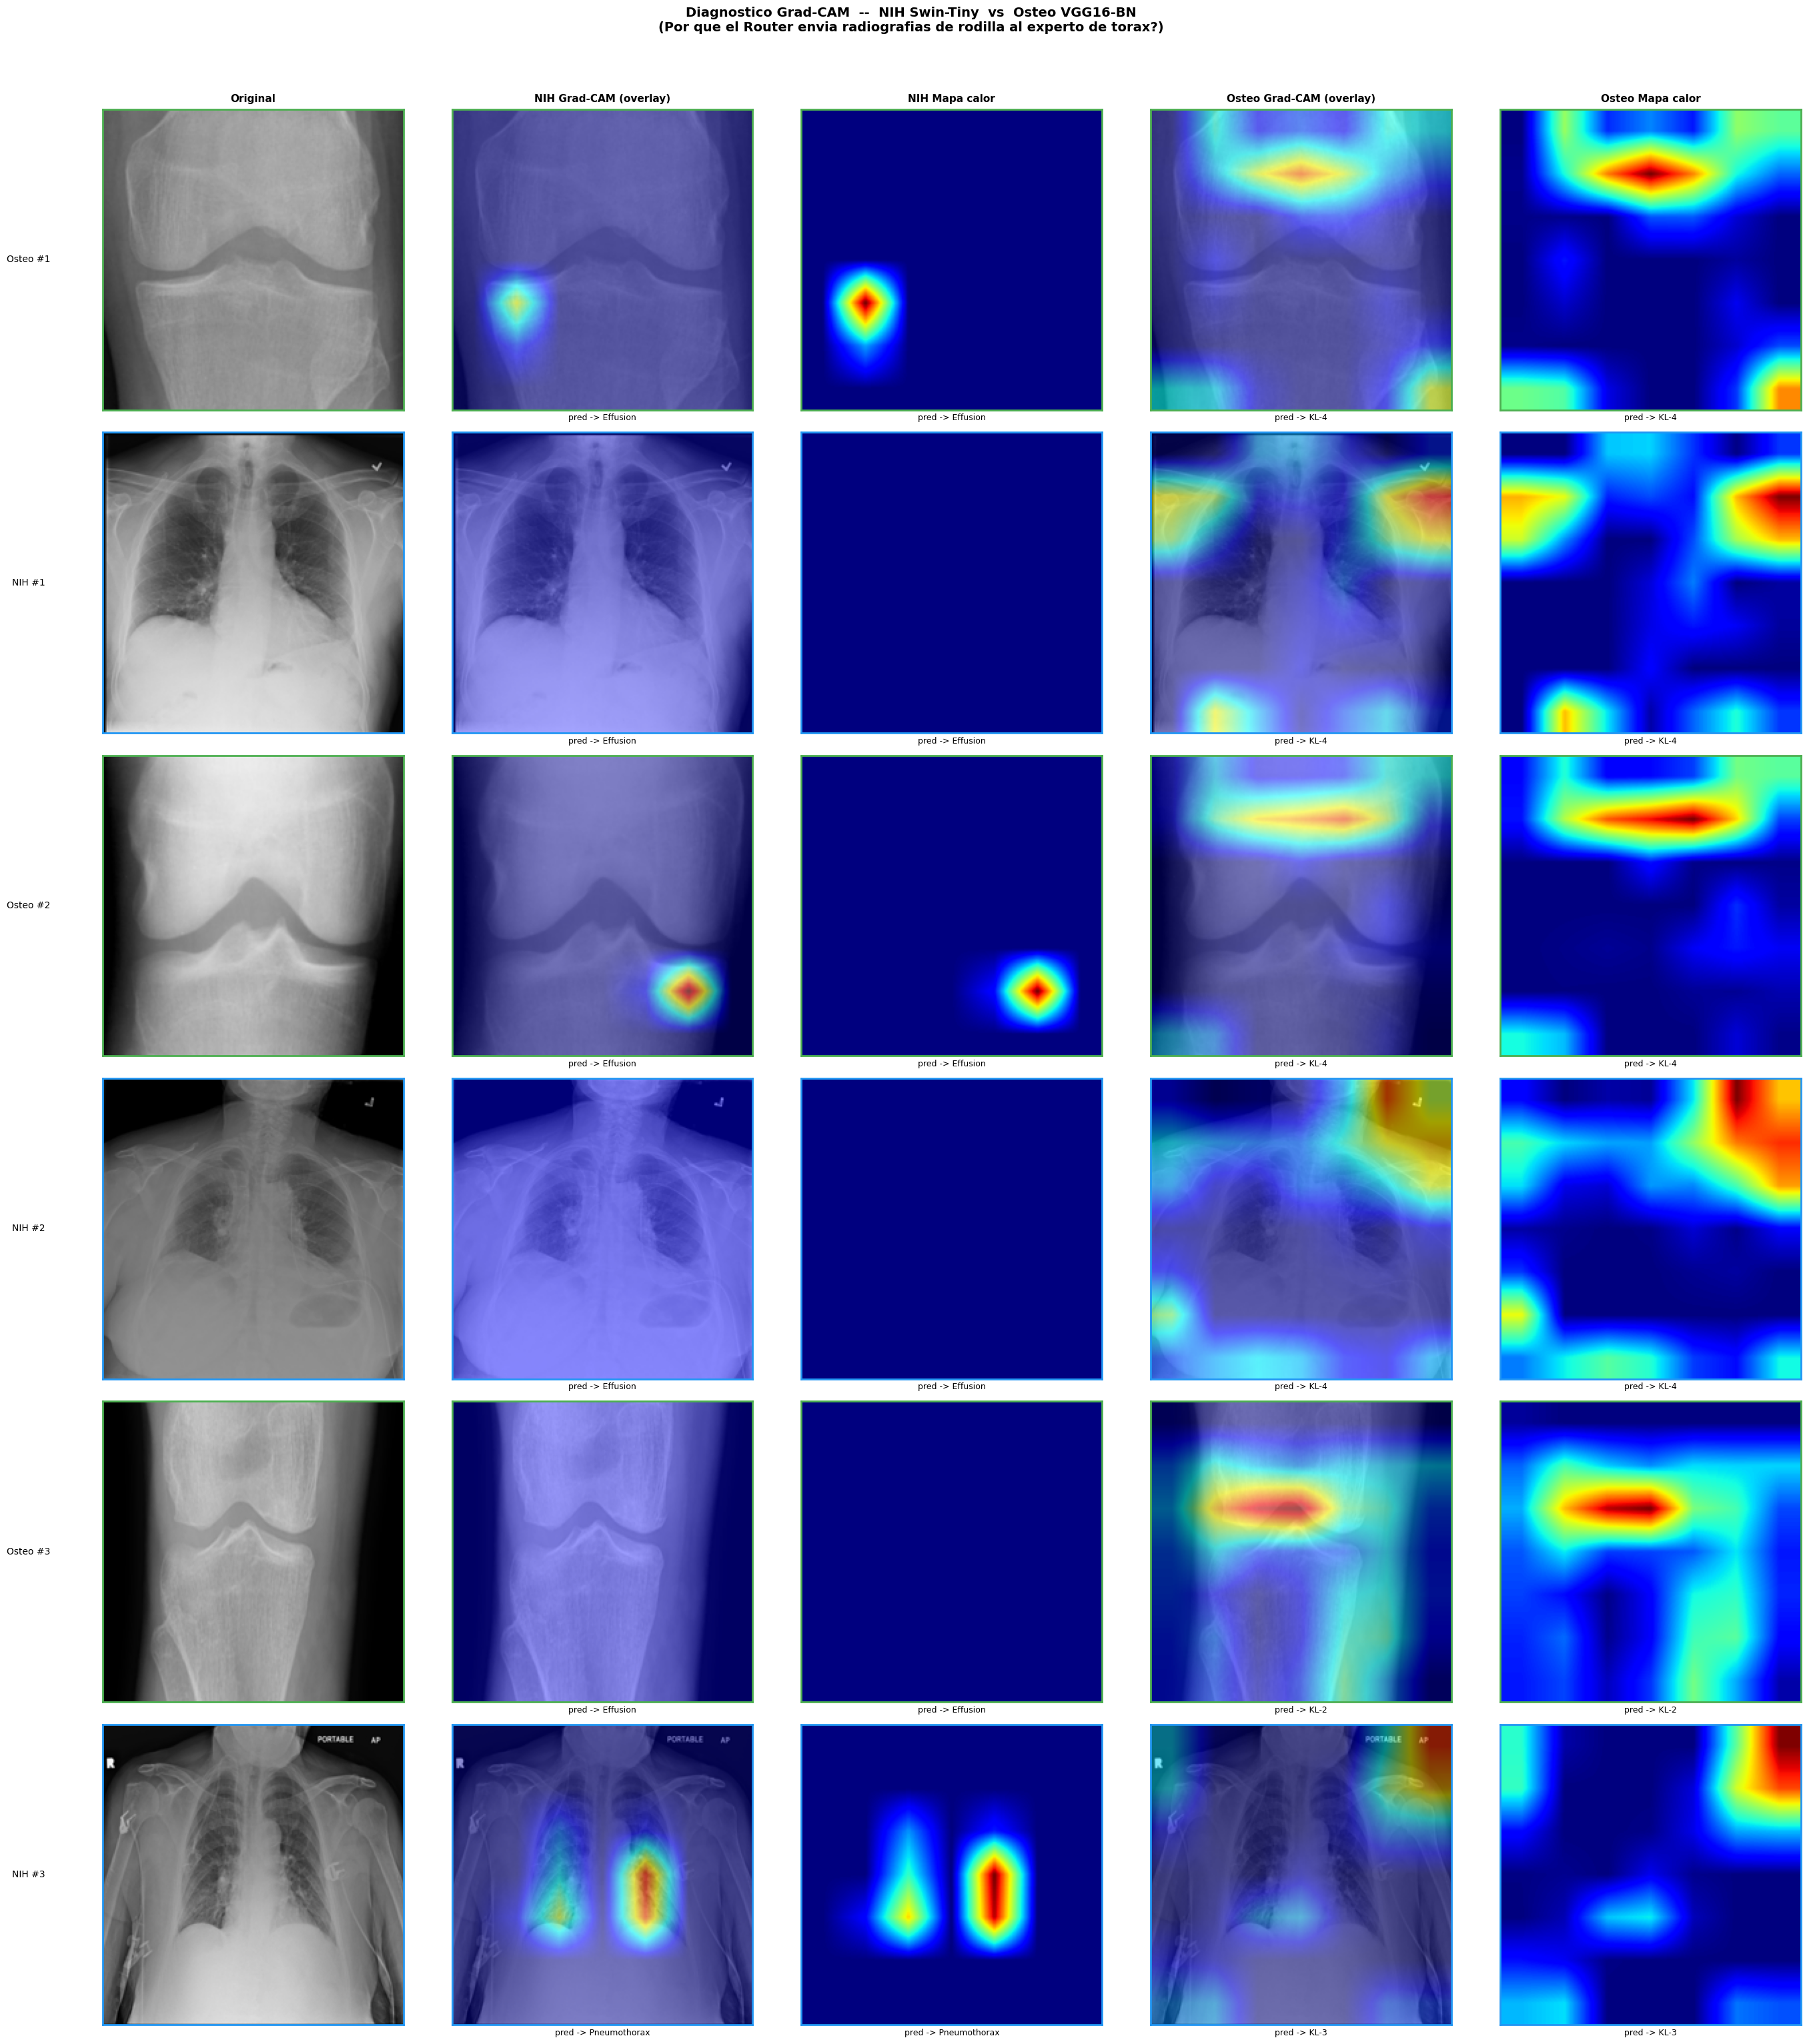


Figura guardada en /content/gradcam_NIH_vs_Osteo.png


In [27]:
n = len(TEST_IMAGES)
fig, axes = plt.subplots(n, 5, figsize=(28, 5 * n))
if n == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    'Diagnostico Grad-CAM  --  NIH Swin-Tiny  vs  Osteo VGG16-BN\n'
    '(Por que el Router envia radiografias de rodilla al experto de torax?)',
    fontsize=14, fontweight='bold', y=1.02
)

COL_NAMES = [
    'Original',
    'NIH Grad-CAM (overlay)',
    'NIH Mapa calor',
    'Osteo Grad-CAM (overlay)',
    'Osteo Mapa calor',
]
for ax, ct in zip(axes[0], COL_NAMES):
    ax.set_title(ct, fontsize=11, fontweight='bold', pad=8)

for row, test in enumerate(TEST_IMAGES):
    path = test['path']
    axs  = axes[row]

    frame_color = '#4CAF50' if test['true_expert'] == 'Osteo' else '#2196F3'
    for ax in axs:
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(frame_color)
            spine.set_linewidth(2)

    axs[0].set_ylabel(
        test['label'], fontsize=10,
        rotation=0, labelpad=80, va='center'
    )

    if not path or not os.path.exists(path):
        axs[0].text(0.5, 0.5, f'Sin imagen:\n{path}',
                    ha='center', va='center', color='red',
                    transform=axs[0].transAxes, fontsize=8)
        continue

    # Imagen original
    img_display = img_for_cam_overlay(path, 'nih')  # RGB para display
    axs[0].imshow(img_display)

    # --- NIH Grad-CAM ---
    try:
        x_nih = preprocess_for_model(path, 'nih')
        with torch.no_grad():
            pred_nih = int(nih_model(x_nih).argmax(dim=1).item())
        targets_nih = [ClassifierOutputTarget(pred_nih)]
        cam_nih = gradcam_nih(input_tensor=x_nih, targets=targets_nih,
                              aug_smooth=True, eigen_smooth=False)[0, :]
        img_vis_nih = img_for_cam_overlay(path, 'nih')
        vis_nih = show_cam_on_image(img_vis_nih, cam_nih, use_rgb=True)
        axs[1].imshow(vis_nih)
        pred_n = NIH_CLASSES[pred_nih] if pred_nih < len(NIH_CLASSES) else f'cls_{pred_nih}'
        axs[1].set_xlabel(f'pred -> {pred_n}', fontsize=9)
        axs[2].imshow(cam_nih, cmap='jet')
        axs[2].set_xlabel(f'pred -> {pred_n}', fontsize=9)
    except Exception as e:
        axs[1].text(0.5, 0.5, f'Error NIH:\n{e}',
                    ha='center', va='center', color='red',
                    transform=axs[1].transAxes, fontsize=7, wrap=True)
        print(f'[NIH GradCAM] {test["label"]}: {e}')

    # --- Osteo Grad-CAM ---
    try:
        x_ost = preprocess_for_model(path, 'osteo')
        with torch.no_grad():
            pred_ost = int(osteo_model(x_ost).argmax(dim=1).item())
        targets_ost = [ClassifierOutputTarget(pred_ost)]
        cam_ost = gradcam_osteo(input_tensor=x_ost, targets=targets_ost,
                                aug_smooth=True, eigen_smooth=False)[0, :]
        img_vis_ost = img_for_cam_overlay(path, 'osteo')
        vis_ost = show_cam_on_image(img_vis_ost, cam_ost, use_rgb=True)
        axs[3].imshow(vis_ost)
        pred_o = OSTEO_CLASSES[pred_ost] if pred_ost < len(OSTEO_CLASSES) else f'cls_{pred_ost}'
        axs[3].set_xlabel(f'pred -> {pred_o}', fontsize=9)
        axs[4].imshow(cam_ost, cmap='jet')
        axs[4].set_xlabel(f'pred -> {pred_o}', fontsize=9)
    except Exception as e:
        axs[3].text(0.5, 0.5, f'Error Osteo:\n{e}',
                    ha='center', va='center', color='red',
                    transform=axs[3].transAxes, fontsize=7, wrap=True)
        print(f'[Osteo GradCAM] {test["label"]}: {e}')

plt.tight_layout()
out_path = '/content/gradcam_NIH_vs_Osteo.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'\nFigura guardada en {out_path}')


## Fase 7: Probabilidades detalladas por imagen

In [28]:
print('=' * 70)
print('Probabilidades detalladas')
print('=' * 70)

for test in TEST_IMAGES:
    path = test['path']
    if not path or not os.path.exists(path):
        print(f'\n[Skip] {test["label"]} -- imagen no encontrada'); continue

    print(f'\n  {test["label"]}  (experto correcto: {test["true_expert"]})')
    print(f'   {path[-70:]}')

    with torch.no_grad():
        p = torch.sigmoid(nih_model(preprocess_for_model(path, 'nih'))).squeeze().cpu().numpy()
    print('   == NIH  Swin-Tiny ==')
    for c, v in zip(NIH_CLASSES, p):
        print(f'      {c:20s}: {v:.4f}  {"|"+"|".join([""]*(int(v*40)))}' if v > 0.01 else f'      {c:20s}: {v:.4f}')

    with torch.no_grad():
        p = torch.softmax(osteo_model(preprocess_for_model(path, 'osteo')), dim=1).squeeze().cpu().numpy()
    print('   == Osteo VGG16-BN ==')
    for c, v in zip(OSTEO_CLASSES, p):
        print(f'      {c:20s}: {v:.4f}  {"|"+"|".join([""]*(int(v*40)))}' if v > 0.01 else f'      {c:20s}: {v:.4f}')

print('\nAnalisis completado.')


Probabilidades detalladas

  Osteo #1  (experto correcto: Osteo)
   ithoutKLGrade/normal/0_336_png.rf.5fdee82e799c16154880daa9b3ecb034.jpg
   == NIH  Swin-Tiny ==
      Mass                : 0.2816  |||||||||||
      Nodule              : 0.3918  |||||||||||||||
      Effusion            : 0.8512  ||||||||||||||||||||||||||||||||||
      Cardiomegaly        : 0.2845  |||||||||||
      Pneumothorax        : 0.4131  ||||||||||||||||
   == Osteo VGG16-BN ==
      KL-0                : 0.0779  |||
      KL-1                : 0.1020  ||||
      KL-2                : 0.0532  ||
      KL-3                : 0.0302  |
      KL-4                : 0.7366  |||||||||||||||||||||||||||||

  NIH #1  (experto correcto: NIH)
   content/datasets/NIH Chest X ray 14/images_012/images/00028247_001.png
   == NIH  Swin-Tiny ==
      Mass                : 0.4836  |||||||||||||||||||
      Nodule              : 0.4610  ||||||||||||||||||
      Effusion            : 0.5856  |||||||||||||||||||||||
      Cardiom

---
## Interpretación

| Columna | ¿Qué revela? |
|---|---|
| **NIH Grad-CAM (HOT)** | Zonas donde el model de tórax se fija. Si activa la región articular de una rodilla → el modelo es demasiado genérico. |
| **Osteo Grad-CAM (SUMMER)** | Debe concentrarse en el **espacio tibiofemoral** (la ranura entre fémur y tibia). |
| **Diferencia (Osteo − NIH)** | 🟢 Verde = solo Osteo activa. 🔴 Rojo = solo NIH activa. Mapa neutro → mismas activaciones → causa del routing erróneo. |

### Marco de filas
- 🟢 **Verde** → imagen es de Osteo (rodilla)  
- 🔵 **Azul** → imagen es de NIH (tórax)

### Posibles soluciones al problema de routing
1. **Subir `ALPHA_TASK`** en el fine-tuning del Router: penalizar más el error específico.  
2. **Pérdida contrastiva** sobre los CLS tokens de NIH y Osteo: alejar sus embeddings.  
3. **Hard negative mining**: imágenes Osteo mal enrutadas → negativas explícitas en el batch del Router.